In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("Cleaned_Sales_Dataset.xlsx")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Month,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,February,Adult
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,October,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,May,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,December,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,November,Middle Age


In [5]:
df.shape

(1000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
 12  Month          1000 non-null   object        
 13  Age_Group      1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(9)
memory usage: 109.5

In [7]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683626,2.838632,14179.402361,114100.051546


In [8]:
df.describe(include='object')

,Order_ID,Customer_ID,Customer_Name,Gender,City,Product,Category,Month,Age_Group
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,992,947,425,2,8,6,5,12,4
top,ORD100050,CUST2515,Customer_359,Male,Patna,Mobile,Electronics,December,Middle Age
freq,9,3,8,511,148,184,354,98,411


In [9]:
df.nunique()

Order_ID          992
Order_Date        342
Customer_ID       947
Customer_Name     425
Age                48
Gender              2
City                8
Product             6
Category            5
Quantity           10
Unit_Price       1000
Total_Sales      1000
Month              12
Age_Group           4
dtype: int64

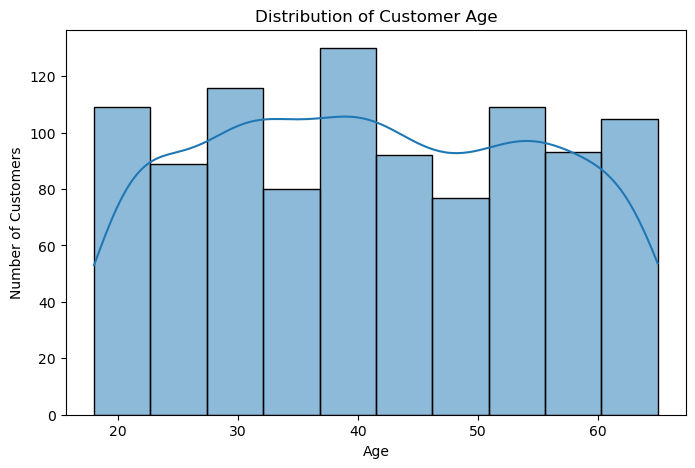

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

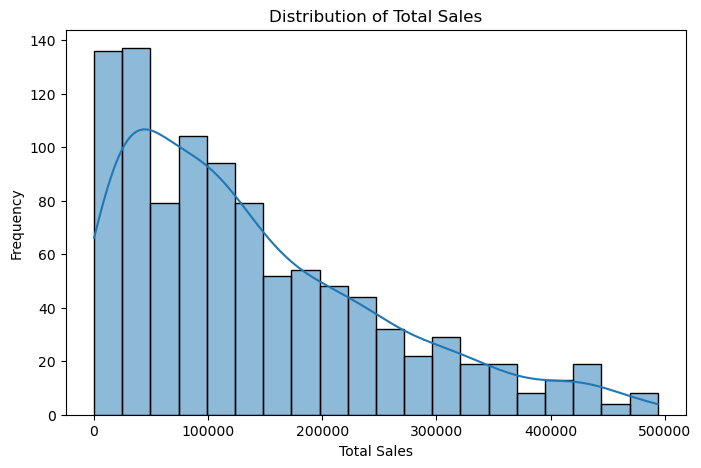

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Sales'], bins=20, kde=True)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

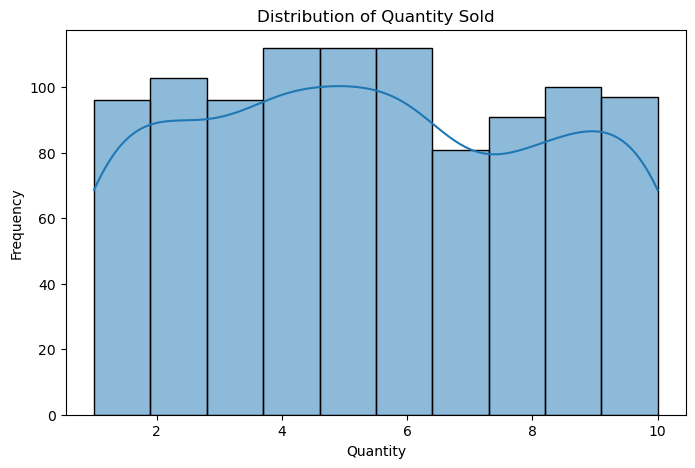

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=10, kde=True)
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

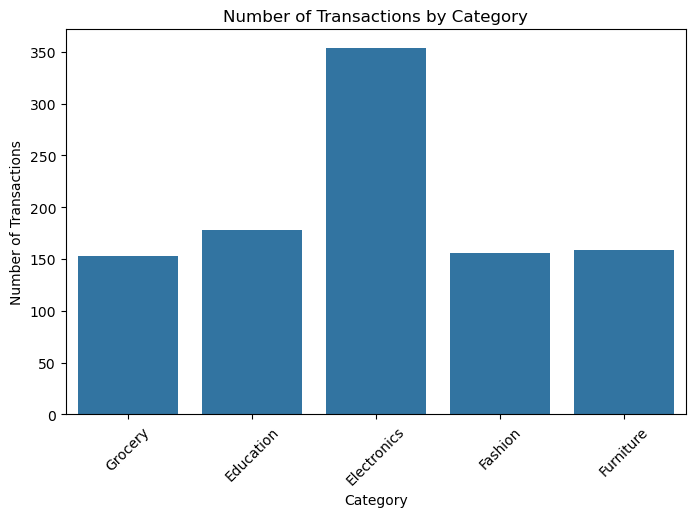

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Category')
plt.title('Number of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

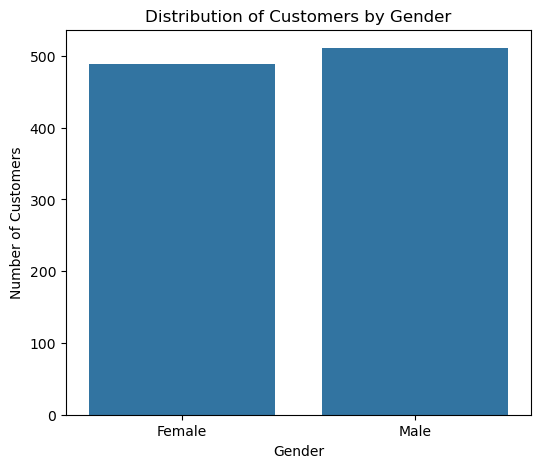

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title('Distribution of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

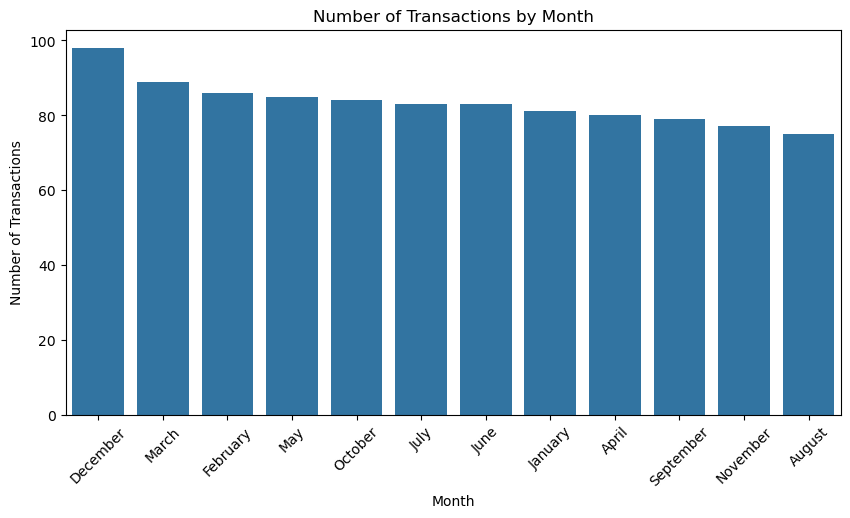

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Month', order=df['Month'].value_counts().index)
plt.title('Number of Transactions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

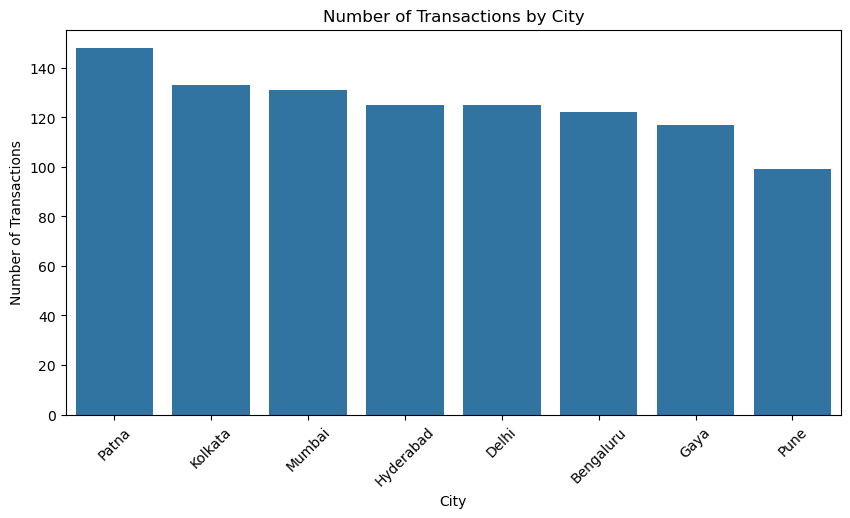

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='City', order=df['City'].value_counts().index)
plt.title('Number of Transactions by City')
plt.xlabel('City')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

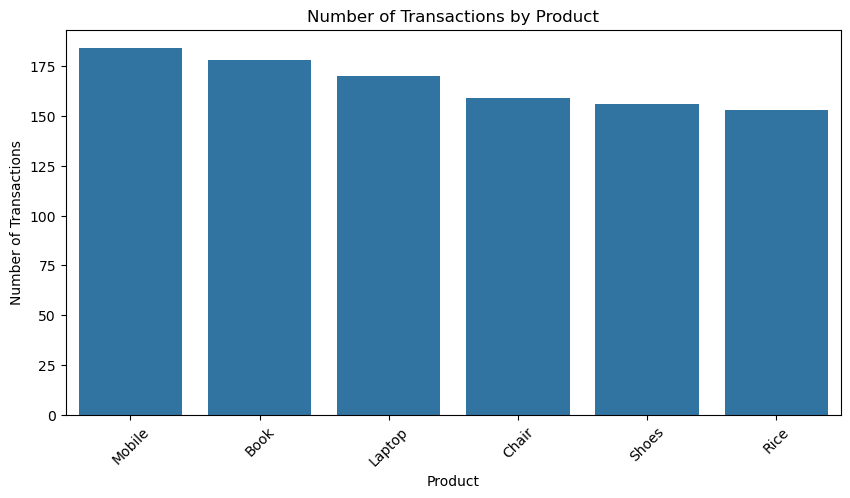

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Product', order=df['Product'].value_counts().index)
plt.title('Number of Transactions by Product')
plt.xlabel('Product')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

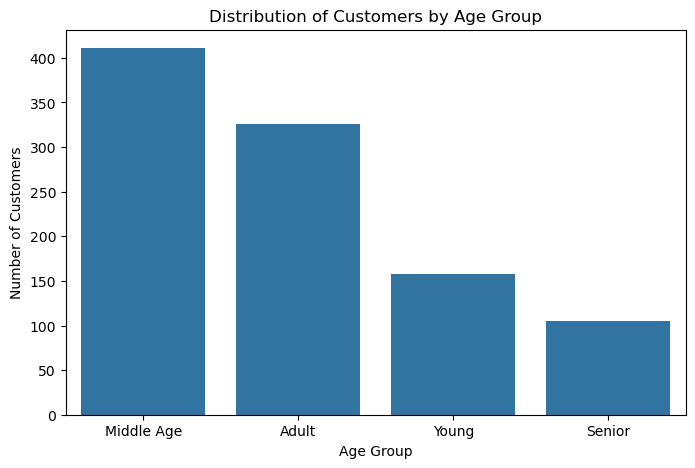

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age_Group', order=df['Age_Group'].value_counts().index)
plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

In [19]:
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

In [20]:
category_sales

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

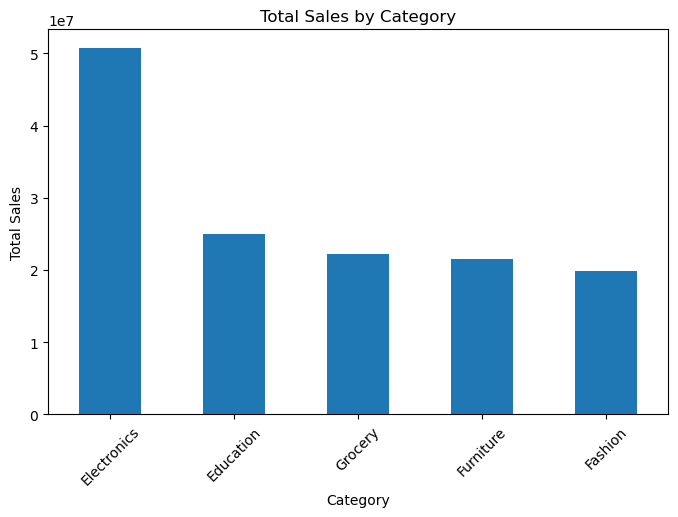

In [22]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [23]:
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

In [24]:
product_sales

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64

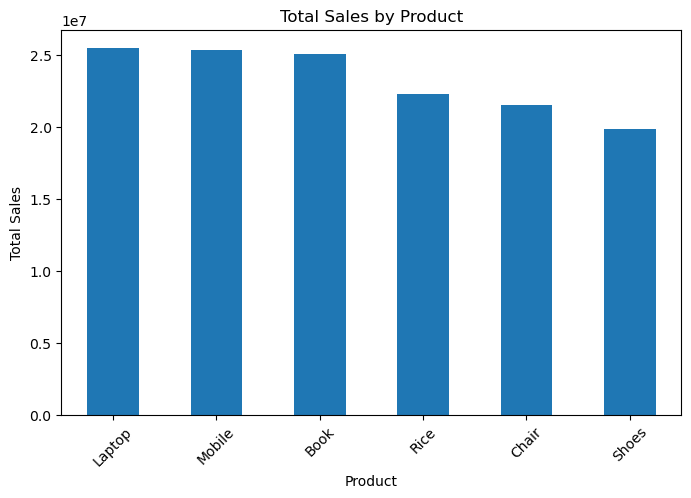

In [25]:
plt.figure(figsize=(8,5))
product_sales.plot(kind='bar')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [26]:
top_5_products = product_sales.head(5)

In [27]:
top_5_products

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Name: Total_Sales, dtype: float64

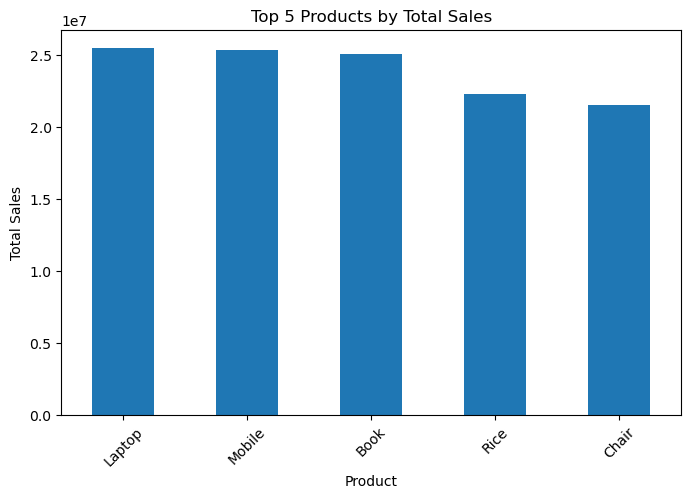

In [28]:
plt.figure(figsize=(8,5))
top_5_products.plot(kind='bar')
plt.title('Top 5 Products by Total Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [29]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

In [30]:
city_sales

City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64

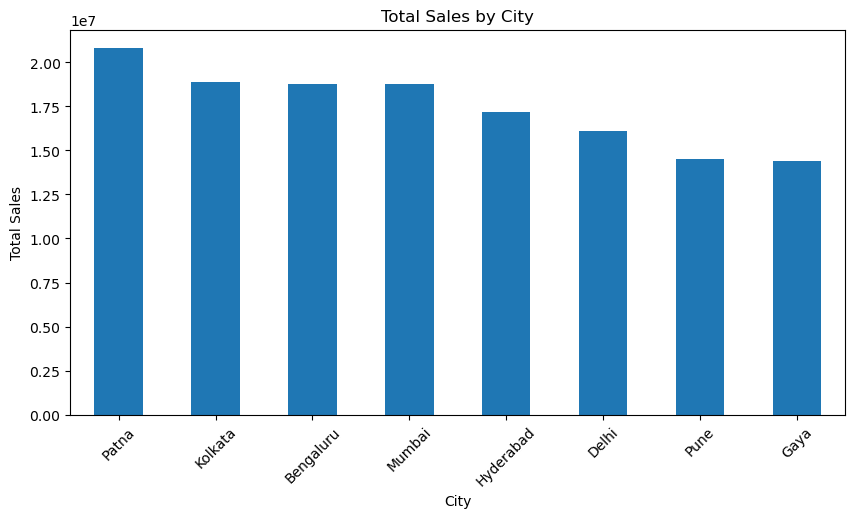

In [31]:
plt.figure(figsize=(10,5))
city_sales.plot(kind='bar')
plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [32]:
top_5_cities = city_sales.head(5)

top_5_cities

City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Name: Total_Sales, dtype: float64

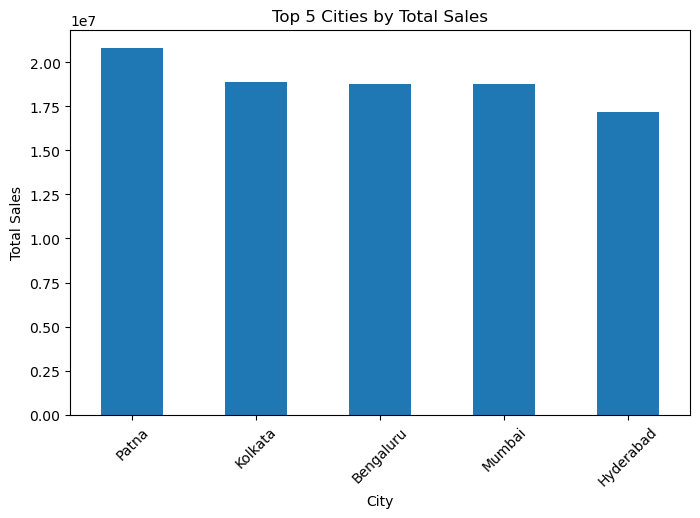

In [33]:
plt.figure(figsize=(8,5))
top_5_cities.plot(kind='bar')
plt.title('Top 5 Cities by Total Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [34]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()
monthly_sales

Month
April        12222700.17
August        9448471.22
December     12299904.44
February     11511181.46
January      10905580.72
July         11746226.80
June         12912332.64
March        13059899.94
May          10984689.25
November     12627620.22
October      12500936.50
September     9179896.29
Name: Total_Sales, dtype: float64

In [35]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

Month
January      10905580.72
February     11511181.46
March        13059899.94
April        12222700.17
May          10984689.25
June         12912332.64
July         11746226.80
August        9448471.22
September     9179896.29
October      12500936.50
November     12627620.22
December     12299904.44
Name: Total_Sales, dtype: float64

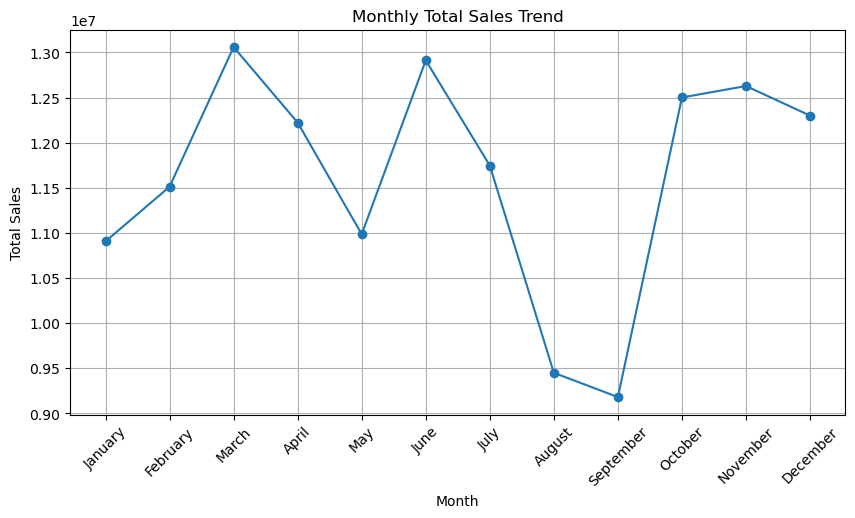

In [36]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [37]:
correlation = df[['Age', 'Quantity', 'Unit_Price', 'Total_Sales']].corr()

correlation

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027666,-0.011955,0.001294
Quantity,-0.027666,1.000000,0.021855,0.646641
Unit_Price,-0.011955,0.021855,1.000000,0.686303
Total_Sales,0.001294,0.646641,0.686303,1.000000


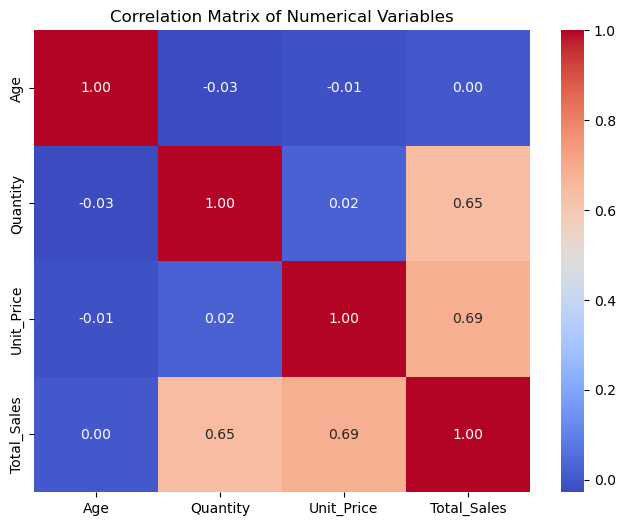

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

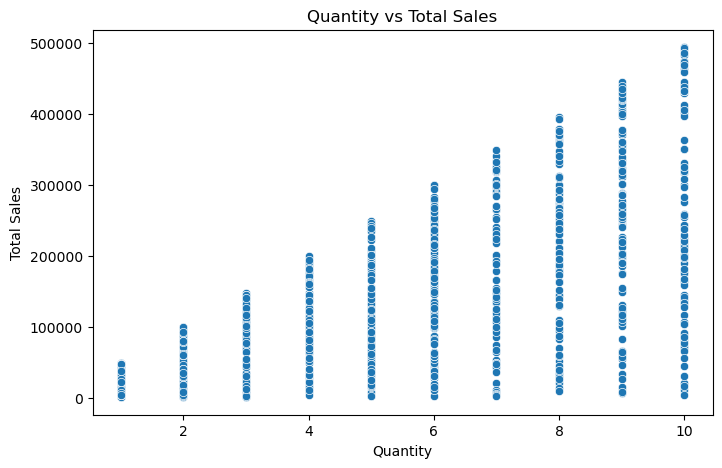

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='Total_Sales')
plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

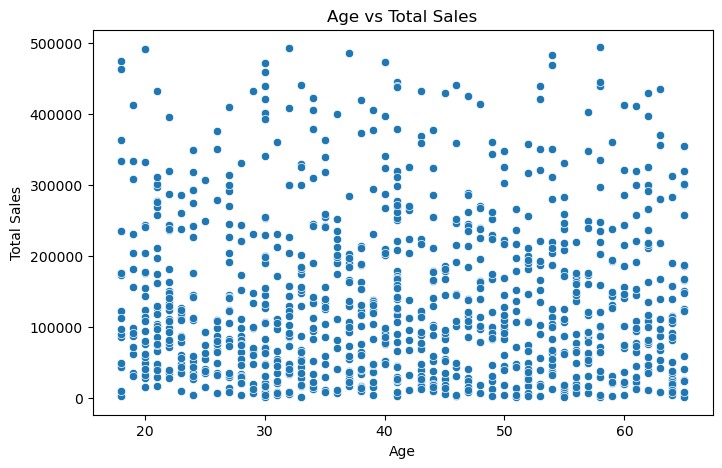

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Total_Sales')
plt.title('Age vs Total Sales')
plt.xlabel('Age')
plt.ylabel('Total Sales')
plt.show()

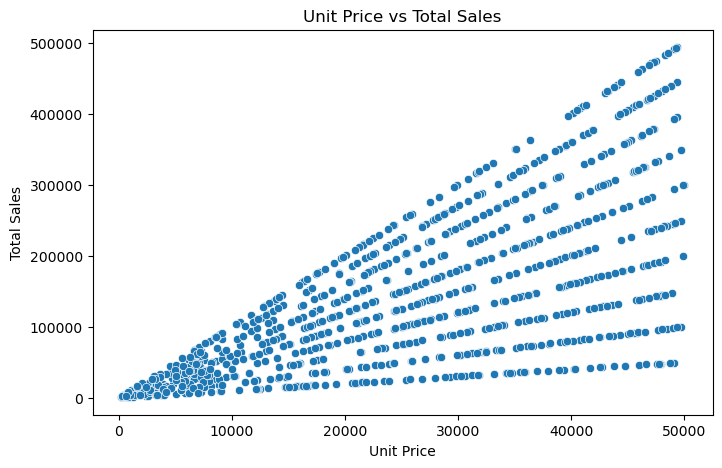

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Unit_Price', y='Total_Sales')
plt.title('Unit Price vs Total Sales')
plt.xlabel('Unit Price')
plt.ylabel('Total Sales')
plt.show()